<a href="https://colab.research.google.com/github/vstimpson/scientific-computing-projects/blob/main/VACS2_Trinity_College_Session8_IA_SciComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NST IA Scientific Computing Session 8

# Numerical Calculus

<hr style="border:1px solid black"> </hr>

## Section 2. Submitting Your Work for Course Credit

You will solve the set of two coupled ordinary differential equations
that describe the evolution of an ecosystem composed of foxes
(predators) and hares (prey), and produce plots presenting the
results. You will then submit a notebook with the code cells you
need and the resulting well-annotated figures.

### The Volterra equations

  The interactions between species in an ecosystem is at the
heart of the study of ecology.
  In particular, the predator-prey relation gives rise
to quite non-trivial dynamics in their population evolution.
  The Volterra equations (or Lotka-Volterra) were proposed
to model the evolution of the simplest ecosystem, with a
predator species and a prey.
  Taking $y_1(t)$ and $y_2(t)$ as the populations of prey
and predator, respectively, the Volterra equations are

\begin{eqnarray*}
{\mathrm{d}y_1 \over \mathrm{d}t} & = & a \, y_1 - b \, y_1 y_2 \\
{\mathrm{d}y_2 \over \mathrm{d}t} & = - & c \, y_2 + d \, y_1 y_2  .
\end{eqnarray*}

  The positive $a$ term quantifies the exponential growth of the prey
population in the absence of predators:  if $b=0$ the first equation
decouples from the second and becomes a simple ODE;
the fact that the offspring number is proportional to the
reproducing population gives rise to an exponential growth.
  The model assumes unlimited food supply for the prey
(in the typical rendering of this problem in terms of hares and
foxes, think of enormous carrot fields available to the hares).
  
  The $b$ term accounts for the decrease of prey population due to
deadly encounters with the predator. The term assumes that such
deaths are proportional to the probability of their meeting,
which is proportional to the product of their respective
populations.
  The equations also assume that hare deaths by other causes are
negligible.
  The second equation considers the predator population
variation to be determined by natural deaths (proportional
to the population itself, leading to exponential decay in the
absence of prey), except if finding prey, simulated by a similar
term as before, with opposite sign of course.

  This extremely simple model gives rise to very rich dynamics,
due to the fact that it is a non linear model (which also makes
it hard for analytic treatment).
  The description, analysis and ecological implications of the
model are beyond the remit of this course, but it serves us
nicely to illustrate the power of numerical approaches.
  NumPy is quite useful here, however, in giving us a very
accessible tool for their numerical exploration.

  We will use the `odeint` numerical integrator of the system
of coupled ODEs. It uses a Runge-Kutta integration algorithm,
as descriibed in the Numerical Recipes cited above, but also here:

https://en.wikipedia.org/wiki/Runge-Kutta_methods


In [ ]:
from scipy.integrate import odeint

- By writing the equations above in a 2-array form, write a
  function, called `volterra(y,t)` returning an array of two
  derivatives when given the array of two values `y` at a given time `t`
  (`y[0]` gives the value of $y_1$ and `y[1]` that of $y_2$).

  You will need to initialise the array of derivatives
  as e.g. `dy = [0., 0.]` if `dy` is the name of the array
  being returned by `volterra`.
  
  Encode in this function the equations above, having first
  initialised the constants in the model to
  
  $$a=c=1, \quad b=0.03, \quad \mathrm{and} \quad d=0.02$$

In [ ]:
def volterra(y, t):
    a = 1.0
    b = 0.03
    c = 1.0
    d = 0.02

    y1, y2 = y[0], y[1]

    dy1_dt = a * y1 - b * y1 * y2
    dy2_dt = -c * y2 + d * y1 * y2

    return [dy1_dt, dy2_dt]

- Define an array of time values, `ts`, for a time span
  between $t=0$ and $t=t_f$, discretised to a total of
  $N$ time values (the fineness of the discretisation being
  $\delta t = \frac{t_f}{N-1}$). Start with e.g. $N = 500$, and $t_f=20$.
- Define the initial population values as a 2-array, e.g.
  `y0 = [100., 10.]` for 100 hares and 10 foxes initially.
- Solve numerically
  the problem using the ``odeint`` solver as follows:
  ```
  sol = odeint(volterra, y0, ts)
  ```
  `sol` should appear as a an ($N$,2) array, being $N$ the
  number of time steps in `ts`.
  Therefore, `sol[:,0]` contains the evolution of the hare
  population and `sol[:,1]` that of foxes.

In [ ]:
import numpy as np

N = 500
tf = 20

ts = np.linspace(0, tf, N)

print(f"Time array 'ts' created with {N} points from t=0 to t={tf}.")
print(f"First 5 time values: {ts[:5]}")
print(f"Last 5 time values: {ts[-5:]}")

Time array 'ts' created with 500 points from t=0 to t=20.
First 5 time values: [0.         0.04008016 0.08016032 0.12024048 0.16032064]
Last 5 time values: [19.83967936 19.87975952 19.91983968 19.95991984 20.        ]


In [ ]:
# Define the initial population values (y0)
y0 = [100., 10.]  # 100 hares and 10 foxes initially

sol = odeint(volterra, y0, ts)

print(f"Solution array 'sol' shape: {sol.shape}")
print(f"First 5 rows of solution:\n{sol[:5]}")

Solution array 'sol' shape: (500, 2)
First 5 rows of solution:
[[100.          10.        ]
 [102.81974689  10.42069361]
 [105.66288998  10.88376585]
 [108.52121576  11.39342888]
 [111.38520299  11.95435249]]


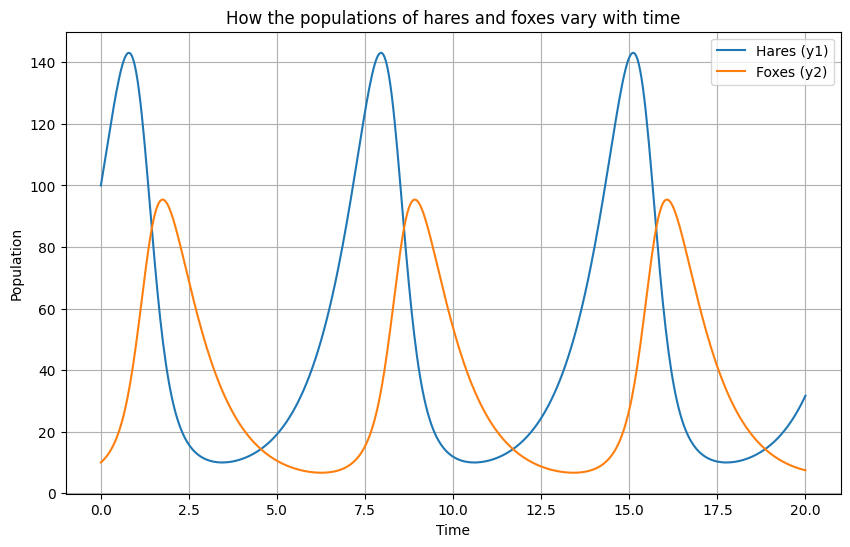

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, sol[:, 0], label='Hares (y1)')
plt.plot(ts, sol[:, 1], label='Foxes (y2)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('How the populations of hares and foxes vary with time')
plt.legend()
plt.grid(True)
plt.show()

- Plot the populations of foxes and hares as a function of time.

- The times sampled by the `ts` array are not the ones
  used for the numerical integration.
  You can see that easily by reducing $N$ to a very
  small number and see that the population values fall
  very accurately on the ones given for a finer sampling.
  
  The algorithm encoded
  in `odeint` generates a number of integration steps per
  sampled step in order to achieve required accuracy.
  
  You can find information abou the integrator in  
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html .
  
  If calling the integrator as
  ```
  sol = odeint(volterra, y0, ts, full_output=True)
  ```
  `sol[1]` will contain a dictionary with information about
  the process. Use
  ```
  sol[1].get('nst')
  ```
  to obtain the numer of time steps per sampled step in an
  array (do it for a small number of sample steps $N$).
  Obtain the total number of integration steps for $t_f = 20$.

In [ ]:
N_small = 10
ts_small = np.linspace(0, tf, N_small)

sol = odeint(volterra, y0, ts_small, full_output=True)

nst_array = sol[1].get('nst')

print(f"Number of sample steps (N): {N_small}")
print(f"Number of internal steps per sampled step (nst array):\n{nst_array}")

# Calculate the total number of integration steps for tf = 20
total_integration_steps = np.sum(nst_array)

print(f"\nTotal number of integration steps for tf={tf}: {total_integration_steps}")

Number of sample steps (N): 10
Number of internal steps per sampled step (nst array):
[ 73 106 125 179 216 234 266 313 337]

Total number of integration steps for tf=20: 1849


- Explore the dependence of these populations' evolution on
  the initial conditions by varying the initial values in
  `y0`. Plot one population versus the other.
  Do that for different sets of initial conditions on the
  same graph, using a different line style for each.

In [ ]:
initial_conditions = [
    [100., 10.],  # Baseline: 100 hares, 10 foxes
    [150., 10.],
    [100., 15.],
    [200., 5.]
]
print("Initial conditions defined:")
for i, y0_val in enumerate(initial_conditions):
    print(f"  Scenario {i+1}: Hares={y0_val[0]}, Foxes={y0_val[1]}")

Initial conditions defined:
  Scenario 1: Hares=100.0, Foxes=10.0
  Scenario 2: Hares=150.0, Foxes=10.0
  Scenario 3: Hares=100.0, Foxes=15.0
  Scenario 4: Hares=200.0, Foxes=5.0


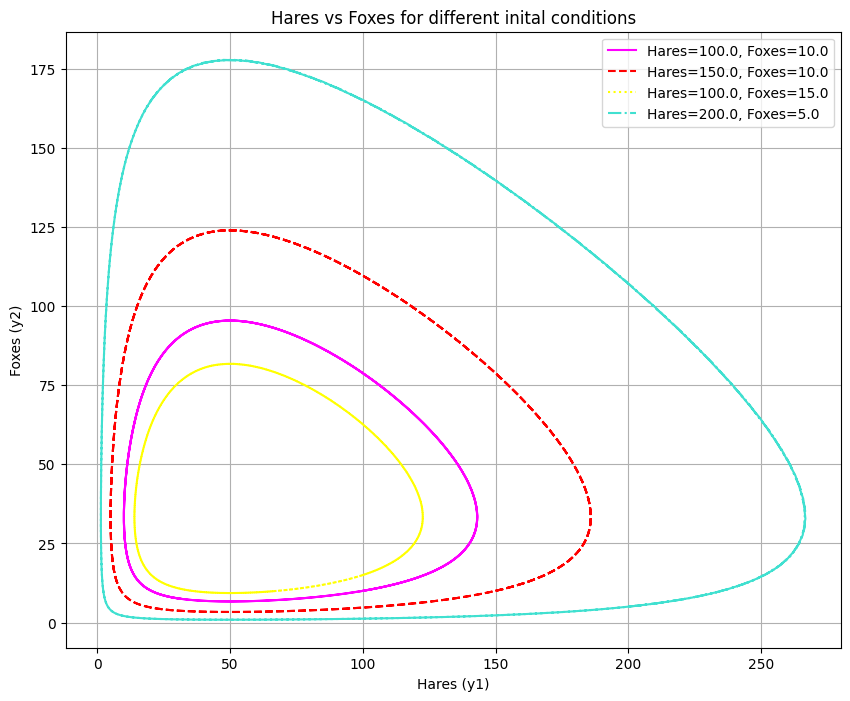

In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.figure(figsize=(10, 8))

colors = ['magenta', 'red', 'yellow', 'turquoise']
linestyles = ['-', '--', ':', '-.']

for i, y0_val in enumerate(initial_conditions):

  sol = odeint(volterra, y0_val, ts)

  plt.plot(sol[:, 0], sol[:, 1],
  color=colors[i % len(colors)],
  linestyle=linestyles[i % len(linestyles)],
  label=f'Hares={y0_val[0]}, Foxes={y0_val[1]}')

plt.xlabel('Hares (y1)')
plt.ylabel('Foxes (y2)')
plt.title('Hares vs Foxes for different inital conditions')
plt.legend()
plt.grid(True)
plt.show()